In [35]:
# Celda 1 Setup inicial: librerías, carga de datasets y verificación
import os
import pandas as pd

os.getcwd()

# Cargar los CSV
df_dc = pd.read_csv("synthetic_datacenter_hourly_3days.csv")
df_tower = pd.read_csv("synthetic_tower_hourly_3days.csv")

# Verificar estructura básica
display(df_dc.head())
display(df_tower.head())

df_dc.columns, df_tower.columns


,timestamp,it_load_kW,hvac_kW,ups_kW,total_consumption_kW,pue,temperature_C
0,2025-01-01 00:00:00,274.908024,100.552212,28.545215,404.005450,1.469602,22.277798
1,2025-01-01 01:00:00,390.142861,181.546143,21.106608,592.795613,1.519432,25.225440
2,2025-01-01 02:00:00,346.398788,170.685734,38.286930,555.371453,1.603272,24.547430
3,2025-01-01 03:00:00,319.731697,172.900717,35.080371,527.712784,1.650486,25.944564
4,2025-01-01 04:00:00,231.203728,177.127035,21.544363,429.875125,1.859291,24.603290


,timestamp,radio_load_kW,battery_soc_%,generator_kW,total_consumption_kW,ambient_temp_C
0,2025-01-01 00:00:00,7.865413,95.860168,0.555987,8.421400,20.370488
1,2025-01-01 01:00:00,10.908333,67.621845,2.463126,13.371458,16.835177
2,2025-01-01 02:00:00,5.305002,100.000000,0.056768,5.361771,11.409387
3,2025-01-01 03:00:00,5.373482,60.479122,2.343303,7.716785,31.618059
4,2025-01-01 04:00:00,13.226006,78.482149,0.281516,13.507522,30.322525


(Index(['timestamp', 'it_load_kW', 'hvac_kW', 'ups_kW', 'total_consumption_kW',
        'pue', 'temperature_C'],
       dtype='object'),
 Index(['timestamp', 'radio_load_kW', 'battery_soc_%', 'generator_kW',
        'total_consumption_kW', 'ambient_temp_C'],
       dtype='object'))

In [36]:
# Celda 2 Preparación y Enriquecimiento Temporal de Datos
import seaborn as sns
import matplotlib.pyplot as plt

# Asegurar formato datetime en la columna 'timestamp'
df_dc['timestamp'] = pd.to_datetime(df_dc['timestamp'])
df_tower['timestamp'] = pd.to_datetime(df_tower['timestamp'])

# Agregar columnas auxiliares para análisis temporal
df_dc['date'] = df_dc['timestamp'].dt.date
df_dc['hour'] = df_dc['timestamp'].dt.hour

df_tower['date'] = df_tower['timestamp'].dt.date
df_tower['hour'] = df_tower['timestamp'].dt.hour


In [37]:
# Celda 2.1 Verificación nombres de columnas
print("Columnas Data Center:")
print(df_dc.columns.tolist())

print("\nColumnas Torre:")
print(df_tower.columns.tolist())


Columnas Data Center:
['timestamp', 'it_load_kW', 'hvac_kW', 'ups_kW', 'total_consumption_kW', 'pue', 'temperature_C', 'date', 'hour']

Columnas Torre:
['timestamp', 'radio_load_kW', 'battery_soc_%', 'generator_kW', 'total_consumption_kW', 'ambient_temp_C', 'date', 'hour']


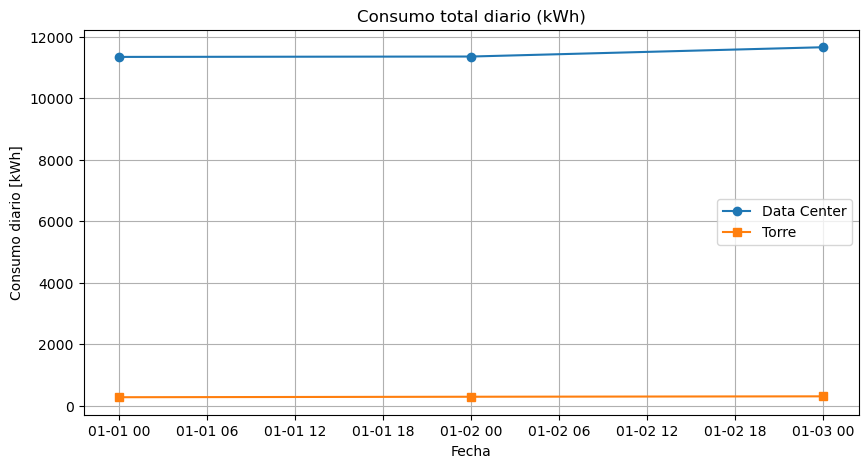

In [38]:
# Paso 2 Visualización de datos
# Celda 3
# ================================
# 🧮 1. Consumo total diario (Data Center y Torre)
# ================================

# Agrupar por fecha y sumar consumo total
dc_daily = df_dc.groupby('date')['total_consumption_kW'].sum()
tower_daily = df_tower.groupby('date')['total_consumption_kW'].sum()

# Graficar
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(dc_daily.index, dc_daily.values, marker='o', label='Data Center')
plt.plot(tower_daily.index, tower_daily.values, marker='s', label='Torre')
plt.title('Consumo total diario (kWh)')
plt.xlabel('Fecha')
plt.ylabel('Consumo diario [kWh]')
plt.grid(True)
plt.legend()
plt.show()


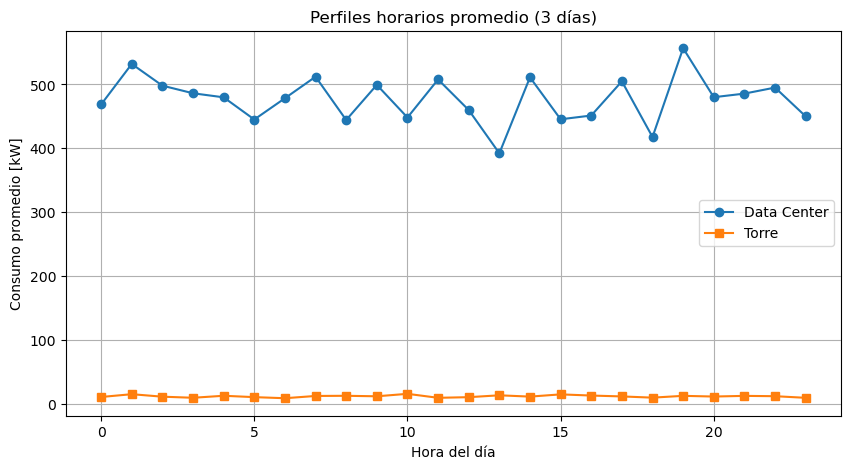

In [39]:
# Paso 2 Visualización de datos
# Celda 4
# ================================
# ⏰ 2. Perfiles horarios promedio
# ================================

# Agrupar por hora y sacar promedio de consumo
dc_hourly_profile = df_dc.groupby('hour')['total_consumption_kW'].mean()
tower_hourly_profile = df_tower.groupby('hour')['total_consumption_kW'].mean()

# Graficar perfiles horarios
plt.figure(figsize=(10,5))
plt.plot(dc_hourly_profile.index, dc_hourly_profile.values, label='Data Center', marker='o')
plt.plot(tower_hourly_profile.index, tower_hourly_profile.values, label='Torre', marker='s')
plt.title('Perfiles horarios promedio (3 días)')
plt.xlabel('Hora del día')
plt.ylabel('Consumo promedio [kW]')
plt.grid(True)
plt.legend()
plt.show()


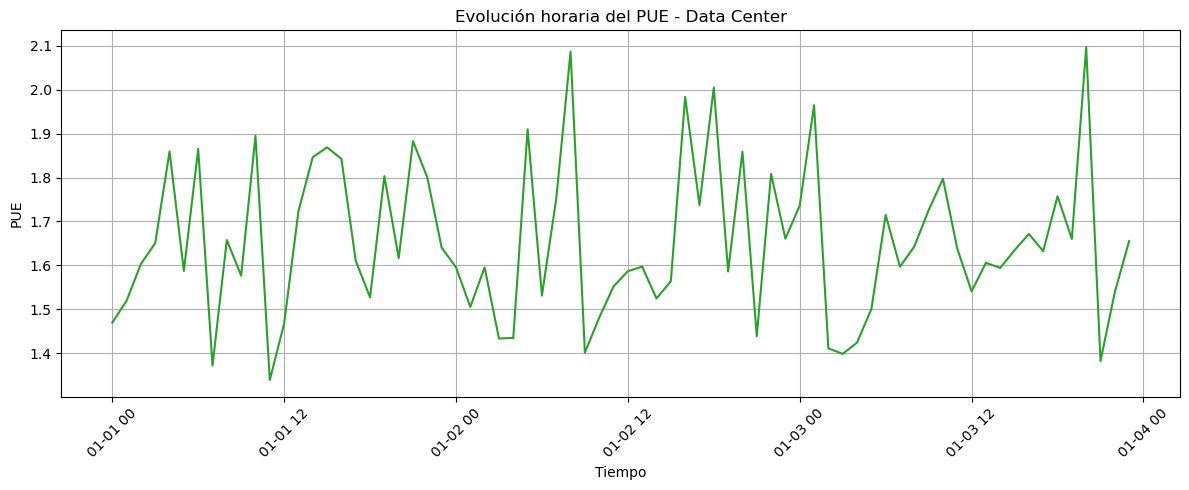

Estadísticas PUE:
count    72.000000
mean      1.652458
std       0.176350
min       1.339146
25%       1.530196
50%       1.624531
75%       1.767270
max       2.097219
Name: pue, dtype: float64


In [40]:
# Paso 2 Visualización de datos
# Celda 5
# ================================
# 📈 3. Evolución de PUE (Data Center)
# ================================

# Calcular PUE horario si no existe como columna calculada
if 'pue' not in df_dc.columns:
    df_dc['pue'] = df_dc['total_consumption_kW'] / df_dc['it_load_kW']

# Graficar evolución temporal del PUE
plt.figure(figsize=(12,5))
plt.plot(df_dc['timestamp'], df_dc['pue'], color='tab:green')
plt.title('Evolución horaria del PUE - Data Center')
plt.xlabel('Tiempo')
plt.ylabel('PUE')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Mostrar valores estadísticos básicos
print("Estadísticas PUE:")
print(df_dc['pue'].describe())


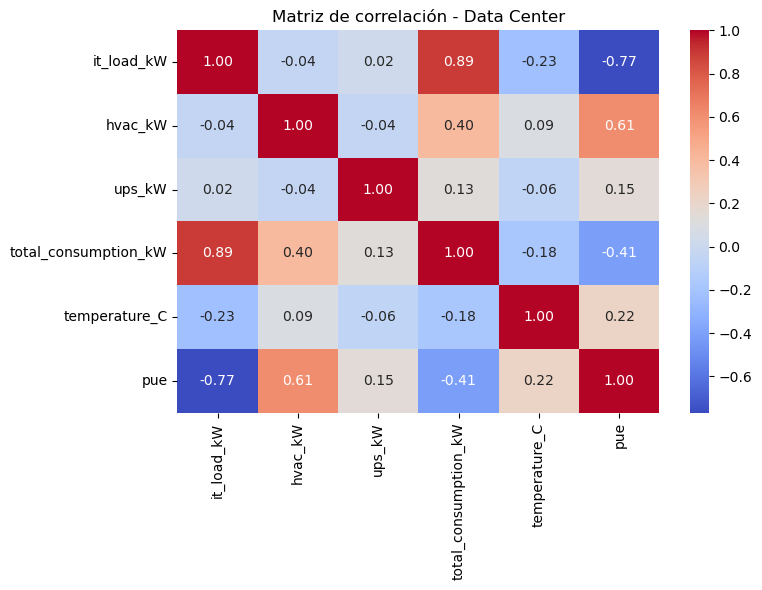

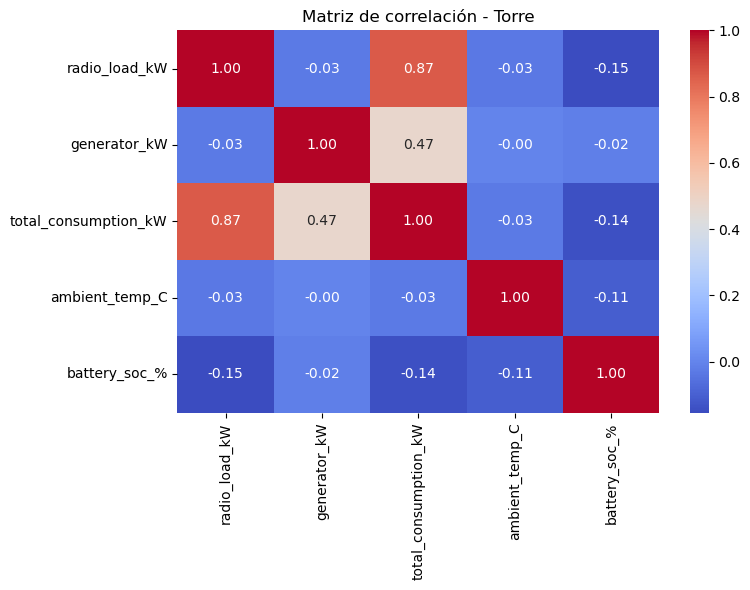

In [41]:
# Paso 2 Visualización de datos
# Celda 6
# ================================
# 🔍 4. Correlaciones rápidas (Heatmap)
# ================================

# Seleccionar columnas numéricas relevantes para Data Center
cols_dc = ['it_load_kW', 'hvac_kW', 'ups_kW', 'total_consumption_kW', 'temperature_C', 'pue']
corr_dc = df_dc[cols_dc].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_dc, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación - Data Center')
plt.tight_layout()
plt.show()

# Seleccionar columnas numéricas relevantes para Torre
cols_tower = ['radio_load_kW', 'generator_kW', 'total_consumption_kW', 'ambient_temp_C', 'battery_soc_%']
corr_tower = df_tower[cols_tower].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_tower, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación - Torre')
plt.tight_layout()
plt.show()


In [42]:
# PASO 3 — PARTE 1
# Celda 7
# --- Paso 3: Limpieza básica y gestión temporal ---

# Convertir la columna 'timestamp' a tipo datetime
df_dc['timestamp'] = pd.to_datetime(df_dc['timestamp'])
df_tower['timestamp'] = pd.to_datetime(df_tower['timestamp'])

# Ordenar por fecha (por si los datos estuvieran desordenados)
df_dc = df_dc.sort_values('timestamp')
df_tower = df_tower.sort_values('timestamp')

# Crear columnas auxiliares de fecha, hora y día de la semana
for df in [df_dc, df_tower]:
    df['date'] = df['timestamp'].dt.date
    df['hour'] = df['timestamp'].dt.hour
    df['weekday'] = df['timestamp'].dt.dayofweek  # 0=lunes, 6=domingo

# Verificar si hay valores nulos o duplicados
print("Nulos Data Center:\n", df_dc.isna().sum())
print("Duplicados Data Center:", df_dc.duplicated().sum())

print("\nNulos Torre:\n", df_tower.isna().sum())
print("Duplicados Torre:", df_tower.duplicated().sum())

# Establecer la columna timestamp como índice temporal
df_dc = df_dc.set_index('timestamp')
df_tower = df_tower.set_index('timestamp')

# Mostrar las primeras filas para confirmar cambios
df_dc.head()


Nulos Data Center:
 timestamp               0
it_load_kW              0
hvac_kW                 0
ups_kW                  0
total_consumption_kW    0
pue                     0
temperature_C           0
date                    0
hour                    0
weekday                 0
dtype: int64
Duplicados Data Center: 0

Nulos Torre:
 timestamp               0
radio_load_kW           0
battery_soc_%           0
generator_kW            0
total_consumption_kW    0
ambient_temp_C          0
date                    0
hour                    0
weekday                 0
dtype: int64
Duplicados Torre: 0


,it_load_kW,hvac_kW,ups_kW,total_consumption_kW,pue,temperature_C,date,hour,weekday
timestamp,,,,,,,,,
2025-01-01 00:00:00,274.908024,100.552212,28.545215,404.005450,1.469602,22.277798,2025-01-01,0,2
2025-01-01 01:00:00,390.142861,181.546143,21.106608,592.795613,1.519432,25.225440,2025-01-01,1,2
2025-01-01 02:00:00,346.398788,170.685734,38.286930,555.371453,1.603272,24.547430,2025-01-01,2,2
2025-01-01 03:00:00,319.731697,172.900717,35.080371,527.712784,1.650486,25.944564,2025-01-01,3,2
2025-01-01 04:00:00,231.203728,177.127035,21.544363,429.875125,1.859291,24.603290,2025-01-01,4,2


In [43]:
# Para confirmar
df_dc.columns


Index(['it_load_kW', 'hvac_kW', 'ups_kW', 'total_consumption_kW', 'pue',
       'temperature_C', 'date', 'hour', 'weekday'],
      dtype='object')

In [44]:
# Para confirmar
df_tower.columns


Index(['radio_load_kW', 'battery_soc_%', 'generator_kW',
       'total_consumption_kW', 'ambient_temp_C', 'date', 'hour', 'weekday'],
      dtype='object')

In [45]:
# PASO 3 — PARTE 2
# Celda 8
# Ingeniería de características

# Para Data Center
df_dc['it_load_kW_lag1'] = df_dc['it_load_kW'].shift(1)  # Lag 1 hora
df_dc['total_consumption_kW_lag1'] = df_dc['total_consumption_kW'].shift(1)

# Rolling mean (media móvil) de 3 horas
df_dc['it_load_kW_roll3'] = df_dc['it_load_kW'].rolling(window=3).mean()
df_dc['total_consumption_kW_roll3'] = df_dc['total_consumption_kW'].rolling(window=3).mean()

# Para Torres
df_tower['radio_load_kW_lag1'] = df_tower['radio_load_kW'].shift(1)
df_tower['total_consumption_kW_lag1'] = df_tower['total_consumption_kW'].shift(1)

df_tower['radio_load_kW_roll3'] = df_tower['radio_load_kW'].rolling(window=3).mean()
df_tower['total_consumption_kW_roll3'] = df_tower['total_consumption_kW'].rolling(window=3).mean()

# Verificamos que las nuevas columnas se hayan agregado correctamente
print("Data Center columns:")
print(df_dc.columns)

print("\nTower columns:")
print(df_tower.columns)


Data Center columns:
Index(['it_load_kW', 'hvac_kW', 'ups_kW', 'total_consumption_kW', 'pue',
       'temperature_C', 'date', 'hour', 'weekday', 'it_load_kW_lag1',
       'total_consumption_kW_lag1', 'it_load_kW_roll3',
       'total_consumption_kW_roll3'],
      dtype='object')

Tower columns:
Index(['radio_load_kW', 'battery_soc_%', 'generator_kW',
       'total_consumption_kW', 'ambient_temp_C', 'date', 'hour', 'weekday',
       'radio_load_kW_lag1', 'total_consumption_kW_lag1',
       'radio_load_kW_roll3', 'total_consumption_kW_roll3'],
      dtype='object')


In [46]:
# PASO 3 — PARTE 3: 
# Celda 9
# Codificación de variables temporales

import numpy as np

# --- Para Data Center ---
# Codificación cíclica de la hora (0-23) → seno y coseno
df_dc['hour_sin'] = np.sin(2 * np.pi * df_dc['hour'] / 24)
df_dc['hour_cos'] = np.cos(2 * np.pi * df_dc['hour'] / 24)

# Codificación cíclica del día de la semana (0=lunes ... 6=domingo)
df_dc['weekday_sin'] = np.sin(2 * np.pi * df_dc['weekday'] / 7)
df_dc['weekday_cos'] = np.cos(2 * np.pi * df_dc['weekday'] / 7)

# --- Para Torres ---
df_tower['hour_sin'] = np.sin(2 * np.pi * df_tower['hour'] / 24)
df_tower['hour_cos'] = np.cos(2 * np.pi * df_tower['hour'] / 24)

df_tower['weekday_sin'] = np.sin(2 * np.pi * df_tower['weekday'] / 7)
df_tower['weekday_cos'] = np.cos(2 * np.pi * df_tower['weekday'] / 7)

# Verificamos que las nuevas columnas estén presentes
print("Data Center columns (últimas):")
print(df_dc.columns[-6:])

print("\nTower columns (últimas):")
print(df_tower.columns[-6:])


Data Center columns (últimas):
Index(['it_load_kW_roll3', 'total_consumption_kW_roll3', 'hour_sin',
       'hour_cos', 'weekday_sin', 'weekday_cos'],
      dtype='object')

Tower columns (últimas):
Index(['radio_load_kW_roll3', 'total_consumption_kW_roll3', 'hour_sin',
       'hour_cos', 'weekday_sin', 'weekday_cos'],
      dtype='object')


In [47]:
# PASO 4 — PARTE 1
# Celda 10
# --- División Train/Test temporal ---

from sklearn.model_selection import train_test_split

# Seleccionar variables predictoras y objetivo para Data Center (ejemplo: predecir total_consumption_kW)
features_dc = [
    'it_load_kW', 'hvac_kW',
    'it_load_kW_lag1', 'total_consumption_kW_lag1', 'it_load_kW_roll3',
    'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'temperature_C'
]
target_dc = 'total_consumption_kW'

# Eliminar filas con valores NaN (por lag/rolling)
df_dc_model = df_dc.dropna(subset=features_dc + [target_dc]).copy()

# División 70% train, 30% test respetando el orden temporal
train_size = int(len(df_dc_model) * 0.7)
train_dc = df_dc_model.iloc[:train_size]
test_dc = df_dc_model.iloc[train_size:]

X_train_dc = train_dc[features_dc]
y_train_dc = train_dc[target_dc]
X_test_dc = test_dc[features_dc]
y_test_dc = test_dc[target_dc]

print("Tamaño train:", X_train_dc.shape)
print("Tamaño test:", X_test_dc.shape)


Tamaño train: (49, 10)
Tamaño test: (21, 10)


Modelo entrenado. Número de coeficientes: 10
📊 Métricas del modelo base — Data Center
RMSE: 13.099 kW
MAE : 11.665 kW
R²  : 0.972


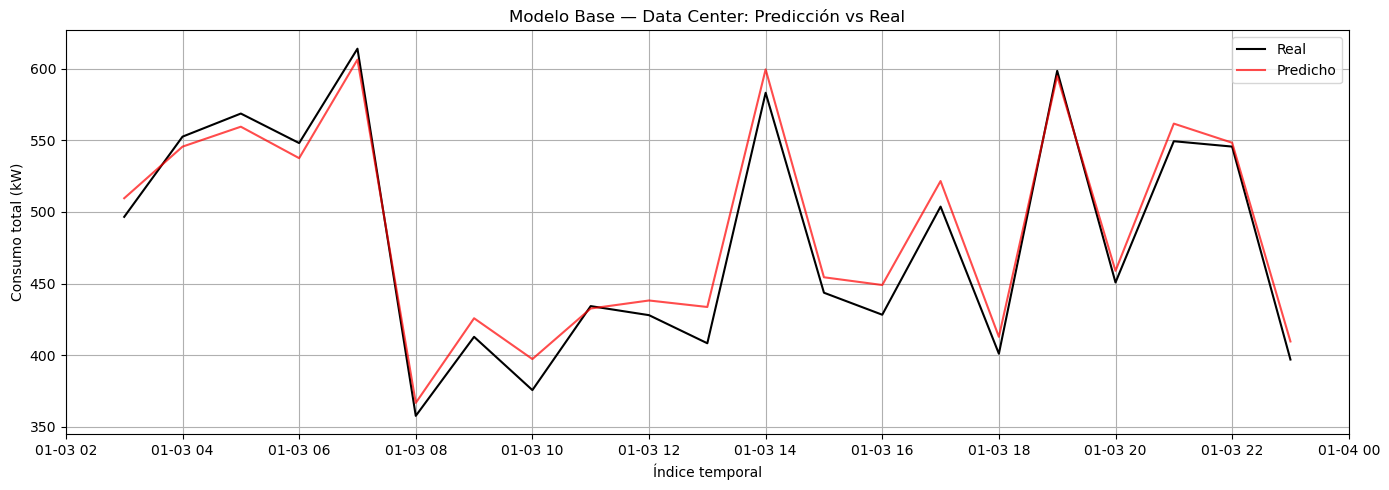

✅ Modelo base entrenado correctamente
Número de variables (coeficientes): 10
Intercepto: 59.2448746163621


In [48]:
# PASO 4 — PARTE 2
# Celda 11
# --- Entrenamiento de modelo base ---

from sklearn.linear_model import LinearRegression

# Crear y entrenar el modelo
model_dc = LinearRegression()
model_dc.fit(X_train_dc, y_train_dc)

# Predicción sobre conjunto de prueba
y_pred_dc = model_dc.predict(X_test_dc)

print("Modelo entrenado. Número de coeficientes:", len(model_dc.coef_))

# # PASO 4 — PARTE 2 Optimizado 1
# Paso 4 — Parte 2: Modelo base de regresión lineal (Data Center)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Inicializar el modelo
model_dc = LinearRegression()

# 2️⃣ Entrenar el modelo con el conjunto de entrenamiento
model_dc.fit(X_train_dc, y_train_dc)

# 3️⃣ Realizar predicciones sobre el conjunto de test
y_pred_dc = model_dc.predict(X_test_dc)

# 4️⃣ Calcular métricas de evaluación
rmse_dc = np.sqrt(mean_squared_error(y_test_dc, y_pred_dc))
mae_dc = mean_absolute_error(y_test_dc, y_pred_dc)
r2_dc = r2_score(y_test_dc, y_pred_dc)

print("📊 Métricas del modelo base — Data Center")
print(f"RMSE: {rmse_dc:.3f} kW")
print(f"MAE : {mae_dc:.3f} kW")
print(f"R²  : {r2_dc:.3f}")

# 5️⃣ Graficar resultados predicción vs realidad
plt.figure(figsize=(14,5))
plt.plot(y_test_dc.index, y_test_dc.values, label='Real', color='black')
plt.plot(y_test_dc.index, y_pred_dc, label='Predicho', color='red', alpha=0.7)
plt.title('Modelo Base — Data Center: Predicción vs Real')
plt.xlabel('Índice temporal')
plt.ylabel('Consumo total (kW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PASO 4 — PARTE 2 (Optimizada 2)
# --- Entrenamiento de modelo base de regresión lineal ---

from sklearn.linear_model import LinearRegression

# Inicializar el modelo
model_dc = LinearRegression()

# Entrenar el modelo con el conjunto de entrenamiento
model_dc.fit(X_train_dc, y_train_dc)

# Generar predicciones sobre el conjunto de prueba
y_pred_dc = model_dc.predict(X_test_dc)

# Mostrar resultados básicos del modelo
print("✅ Modelo base entrenado correctamente")
print(f"Número de variables (coeficientes): {len(model_dc.coef_)}")
print("Intercepto:", model_dc.intercept_)



In [49]:
# PASO 4 — PARTE 3
# Celda 12
# --- Evaluación del modelo base ---

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_dc, y_pred_dc)
rmse = np.sqrt(mean_squared_error(y_test_dc, y_pred_dc))
r2 = r2_score(y_test_dc, y_pred_dc)

print(f"MAE: {mae:.2f} kW")
print(f"RMSE: {rmse:.2f} kW")
print(f"R²: {r2:.3f}")


MAE: 11.66 kW
RMSE: 13.10 kW
R²: 0.972


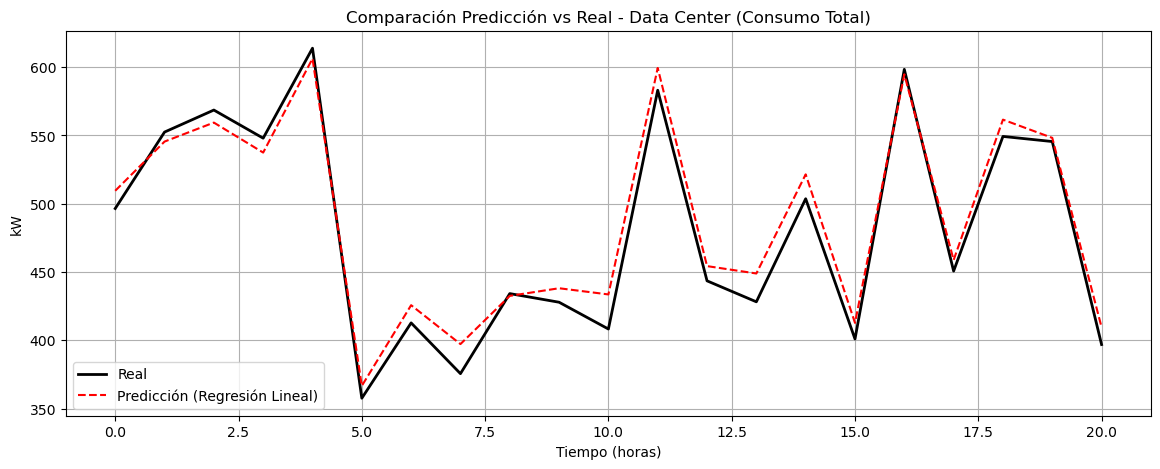

In [50]:
# PASO 4 — PARTE 4
# Celda 13
# --- Visualización de desempeño ---

import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test_dc.values, label='Real', color='black', linewidth=2)
plt.plot(y_pred_dc, label='Predicción (Regresión Lineal)', color='red', linestyle='--')
plt.title('Comparación Predicción vs Real - Data Center (Consumo Total)')
plt.xlabel('Tiempo (horas)')
plt.ylabel('kW')
plt.legend()
plt.grid(True)
plt.show()


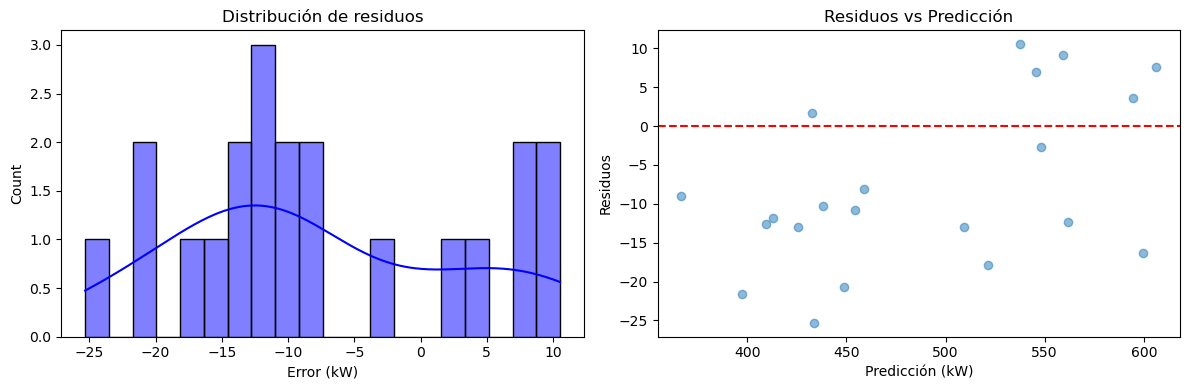

In [51]:
# Parte 4.5 — Diagnóstico del modelo base (Regresión Lineal)
# Celda 14
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calcular residuos
residuos = y_test_dc - y_pred_dc

# Histograma de residuos
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(residuos, bins=20, kde=True, color='blue')
plt.title('Distribución de residuos')
plt.xlabel('Error (kW)')

# Residuos vs Predicción
plt.subplot(1,2,2)
plt.scatter(y_pred_dc, residuos, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs Predicción')
plt.xlabel('Predicción (kW)')
plt.ylabel('Residuos')
plt.tight_layout()
plt.show()


In [52]:
# Parte 4.6 — Regularización Ridge / Lasso
# Celda 15
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_dc, y_train_dc)
y_pred_ridge = ridge_model.predict(X_test_dc)

# Lasso
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_dc, y_train_dc)
y_pred_lasso = lasso_model.predict(X_test_dc)

# Evaluación rápida
def eval_model(y_true, y_pred, name):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    r2 = 1 - np.sum((y_true - y_pred)**2)/np.sum((y_true - np.mean(y_true))**2)
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}")

eval_model(y_test_dc, y_pred_dc, "Lineal base")
eval_model(y_test_dc, y_pred_ridge, "Ridge")
eval_model(y_test_dc, y_pred_lasso, "Lasso")


Lineal base: MAE=11.66, RMSE=13.10, R²=0.972
Ridge: MAE=10.18, RMSE=11.22, R²=0.979
Lasso: MAE=11.44, RMSE=12.79, R²=0.973


                    Variable  Coeficiente (Ridge)
0                 it_load_kW            56.536764
1                    hvac_kW            26.031733
7                weekday_sin            -3.439276
3  total_consumption_kW_lag1             2.605804
8                weekday_cos             2.036230
4           it_load_kW_roll3            -1.712569
6                   hour_cos            -1.573047
5                   hour_sin            -1.378070
9              temperature_C            -0.906618
2            it_load_kW_lag1             0.174172


C:\Users\PGF\AppData\Local\Temp\ipykernel_23760\4164772491.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coeficiente (Ridge)', y='Variable', palette='viridis')


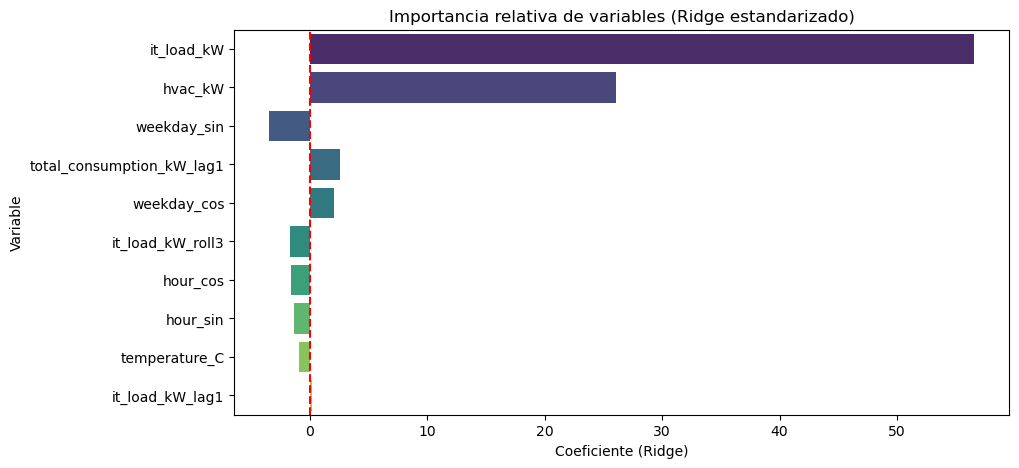

In [63]:
# Parte 4.7 — Estandarización y análisis de coeficientes
# Celda 16
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline con escalamiento + Ridge (como ejemplo)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

pipeline.fit(X_train_dc, y_train_dc)
y_pred_scaled = pipeline.predict(X_test_dc)

# Extraer coeficientes escalados
coeficientes = pipeline.named_steps['model'].coef_
variables = X_train_dc.columns

coef_df = pd.DataFrame({'Variable': variables, 'Coeficiente (Ridge)': coeficientes})
coef_df = coef_df.sort_values(by='Coeficiente (Ridge)', key=abs, ascending=False)
print(coef_df)

# Visualización de importancia
plt.figure(figsize=(10,5))
sns.barplot(data=coef_df, x='Coeficiente (Ridge)', y='Variable', palette='viridis')
plt.title('Importancia relativa de variables (Ridge estandarizado)')
plt.axvline(0, color='red', linestyle='--')
plt.show()


In [64]:
# PASO 5 — PARTE 1
# Celda 17
# --- Modelo Random Forest ---

from sklearn.ensemble import RandomForestRegressor

# Crear y entrenar el modelo
rf_model = RandomForestRegressor(
    n_estimators=300,      # número de árboles
    max_depth=None,       # sin límite de profundidad
    random_state=42,
    n_jobs=-1             # usar todos los núcleos disponibles
)
rf_model.fit(X_train_dc, y_train_dc)

# Predicciones sobre test
y_pred_rf = rf_model.predict(X_test_dc)

print("✅ Random Forest entrenado correctamente.")
print(f"Número de muestras de entrenamiento: {len(y_train_dc)}")
print(f"Número de muestras de prueba: {len(y_test_dc)}")


✅ Random Forest entrenado correctamente.
Número de muestras de entrenamiento: 49
Número de muestras de prueba: 21


In [65]:
# PASO 5 — PARTE 2
# Celda 18
# Evaluación del modelo RF
# Crear y entrenar el modelo Random Forest
from sklearn.ensemble import RandomForestRegressor


model_rf = RandomForestRegressor(
    n_estimators=200,      # número de árboles
    max_depth=10,         # profundidad máxima (controla sobreajuste)
    random_state=42,
    n_jobs=-1             # usar todos los núcleos disponibles
)
model_rf.fit(X_train_dc, y_train_dc)

# Predicción
y_pred_rf = model_rf.predict(X_test_dc)

print("Modelo Random Forest entrenado correctamente.")


Modelo Random Forest entrenado correctamente.


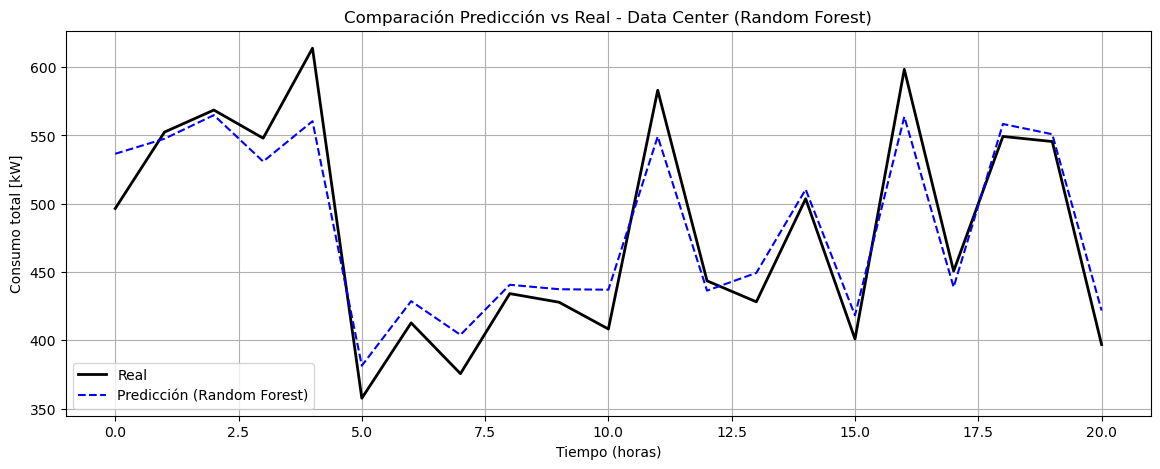

In [66]:
# PASO 5 — PARTE 3
# Celda 19
# --- Visualización de predicción Random Forest vs Real ---

import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test_dc.values, label='Real', color='black', linewidth=2)
plt.plot(y_pred_rf, label='Predicción (Random Forest)', color='blue', linestyle='--')
plt.title('Comparación Predicción vs Real - Data Center (Random Forest)')
plt.xlabel('Tiempo (horas)')
plt.ylabel('Consumo total [kW]')
plt.legend()
plt.grid(True)
plt.show()



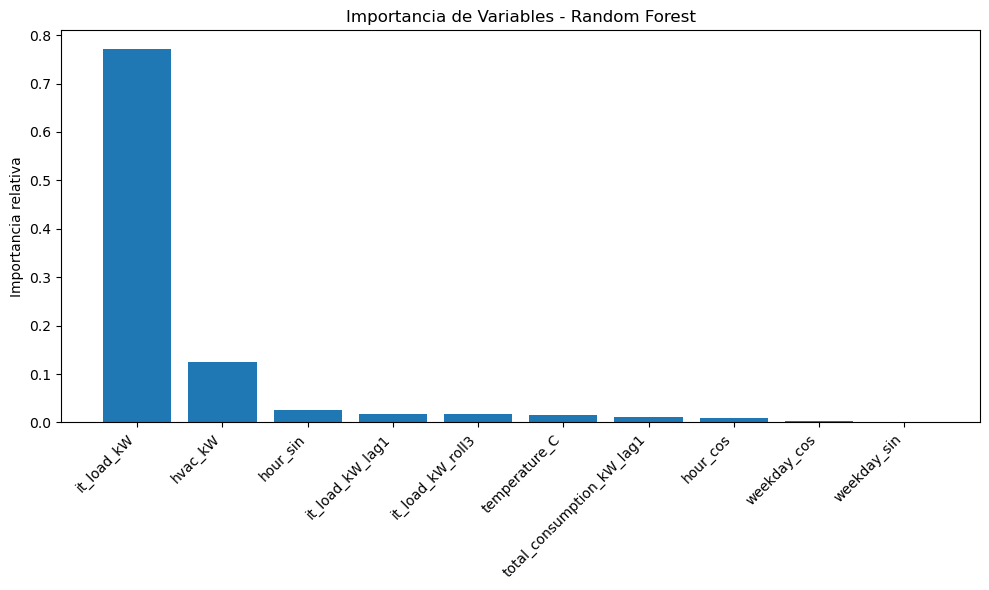

In [67]:
# PASO 5 — PARTE 4
# Celda 20
# --- Importancia de variables en Random Forest ---

import numpy as np
import matplotlib.pyplot as plt

# Obtener importancia de cada variable
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]  # ordenar de mayor a menor

# Graficar importancia
plt.figure(figsize=(10,6))
plt.title("Importancia de Variables - Random Forest")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [features_dc[i] for i in indices], rotation=45, ha='right')
plt.ylabel("Importancia relativa")
plt.tight_layout()
plt.show()


In [68]:
# PASO 6 — PARTE 1
# Celda 21
# --- Interpretabilidad Global con SHAP ---

import shap

# Crear un "explainer" para el modelo RF entrenado
explainer = shap.TreeExplainer(model_rf)

# Calcular valores SHAP para el conjunto de test
shap_values = explainer.shap_values(X_test_dc)


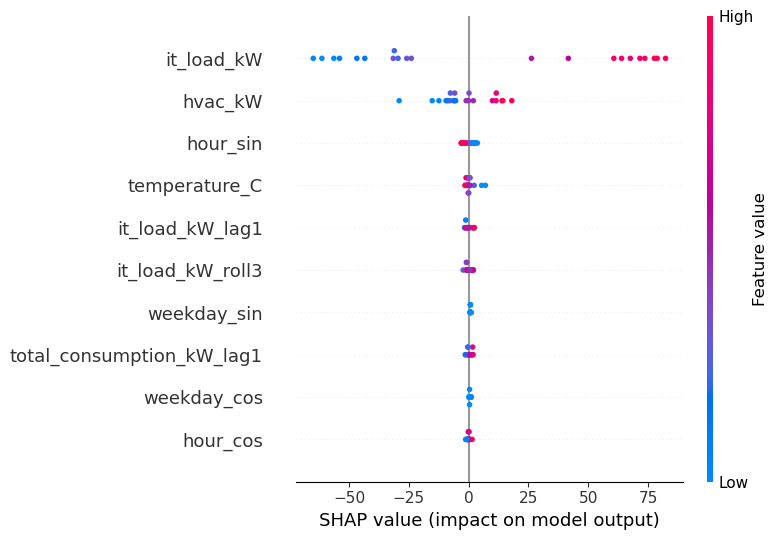

In [69]:
# PASO 6 — PARTE 2
# Celda 22
# --- Interpretabilidad Global con SHAP (Gráfico resumen) ---

shap.summary_plot(shap_values, X_test_dc, plot_type="dot")


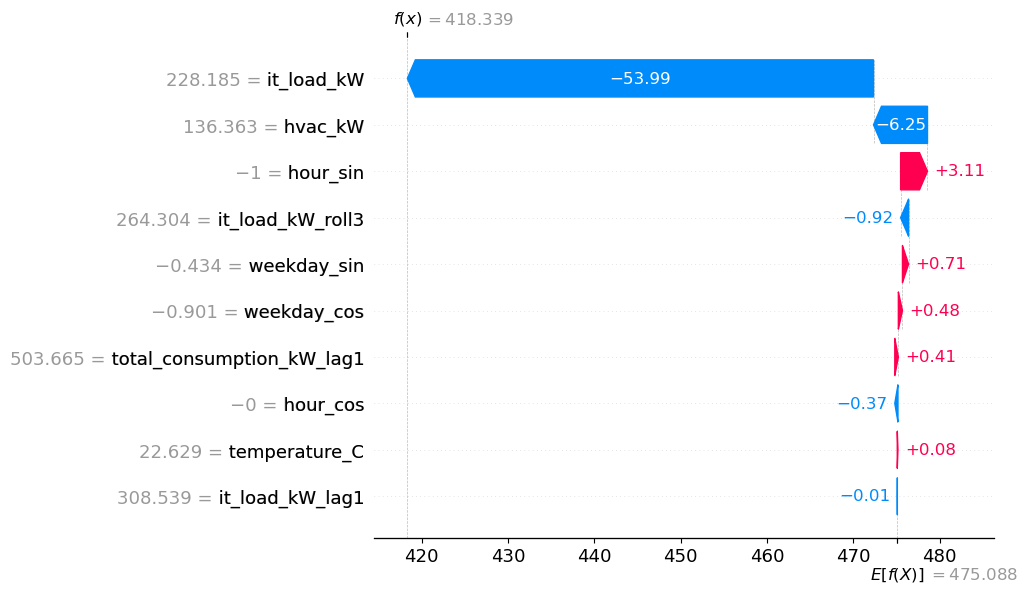

In [70]:
# PASO 6 — PARTE 3
# Celda 23
# --- Interpretabilidad Local con SHAP ---

# Elegimos un índice de ejemplo dentro del set de prueba
# Puedes cambiar el número para analizar distintos momentos
idx = 15

# Crear gráfico de explicación local (tipo waterfall)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_dc.iloc[idx],
        feature_names=X_test_dc.columns
    )
)


In [71]:
# PASO 6 — PARTE 3B (Versión mejorada con verificación de índices)
# Celda 24
import shap
import matplotlib.pyplot as plt
import os

# Ver cuántas observaciones tiene el set de prueba
n_obs = len(X_test_dc)
print(f"El conjunto de prueba tiene {n_obs} observaciones")

# Seleccionamos dinámicamente índices válidos: inicio, medio y fin
indices_to_analyze = sorted(set([0, n_obs//4, n_obs//2, 3*n_obs//4, n_obs-1]))
print(f"Índices seleccionados para análisis: {indices_to_analyze}")

# Carpeta de salida para guardar imágenes
output_folder = "shap_local_plots"
os.makedirs(output_folder, exist_ok=True)

for idx in indices_to_analyze:
    # Crear la explicación local para este índice
    explanation = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_dc.iloc[idx],
        feature_names=X_test_dc.columns
    )

    # Crear gráfico tipo waterfall
    plt.figure()
    shap.plots.waterfall(explanation, show=False)
    plt.title(f"Explicación Local - Índice {idx}")
    
    # Guardar imagen en carpeta
    filename = f"{output_folder}/shap_waterfall_idx_{idx}.png"
    plt.savefig(filename, bbox_inches="tight")
    plt.close()

print(f"✅ Se han generado gráficos locales SHAP en la carpeta '{output_folder}'")


El conjunto de prueba tiene 21 observaciones
Índices seleccionados para análisis: [0, 5, 10, 15, 20]
✅ Se han generado gráficos locales SHAP en la carpeta 'shap_local_plots'


In [72]:
# --- RECONSTRUCCIÓN DE CONTEXTO PARA PASO 7 ---
import pandas as pd
import numpy as np

# Cargar nuevamente los datos base
df_dc = pd.read_csv("synthetic_datacenter_hourly_3days.csv")

# Crear las columnas de fecha y hora (si no existen)
df_dc['timestamp'] = pd.to_datetime(df_dc.index, unit='h', origin='2025-01-01')
df_dc['date'] = df_dc['timestamp'].dt.date
df_dc['hour'] = df_dc['timestamp'].dt.hour
df_dc['weekday'] = df_dc['timestamp'].dt.weekday

# Variables derivadas básicas (lags y rolling) del paso 3
df_dc['it_load_kW_lag1'] = df_dc['it_load_kW'].shift(1)
df_dc['total_consumption_kW_lag1'] = df_dc['total_consumption_kW'].shift(1)
df_dc['it_load_kW_roll3'] = df_dc['it_load_kW'].rolling(window=3).mean()

# Features temporales (senoidales) del paso 3
df_dc['hour_sin'] = np.sin(2 * np.pi * df_dc['hour'] / 24)
df_dc['hour_cos'] = np.cos(2 * np.pi * df_dc['hour'] / 24)
df_dc['weekday_sin'] = np.sin(2 * np.pi * df_dc['weekday'] / 7)
df_dc['weekday_cos'] = np.cos(2 * np.pi * df_dc['weekday'] / 7)

# Limpiar datos NaN (por lag/rolling)
df_dc_model = df_dc.dropna(subset=['it_load_kW', 'total_consumption_kW']).copy()

print("Contexto recreado correctamente ✅")
print("Columnas disponibles:", df_dc_model.columns.tolist())


Contexto recreado correctamente ✅
Columnas disponibles: ['timestamp', 'it_load_kW', 'hvac_kW', 'ups_kW', 'total_consumption_kW', 'pue', 'temperature_C', 'date', 'hour', 'weekday', 'it_load_kW_lag1', 'total_consumption_kW_lag1', 'it_load_kW_roll3', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos']


In [73]:
# Celda 24
# PASO 7 — PARTE 1
# --- Simulación del escenario ISO 50001 tradicional (gestión reactiva) ---

import numpy as np
import pandas as pd

# Copiar el dataset base del data center (de los pasos anteriores)
df_iso = df_dc_model.copy()

# Simular acción correctiva con retardo (reacción a desviación anterior)
# La corrección solo ocurre una hora después de detectar sobreconsumo
df_iso['pred_iso'] = df_iso['total_consumption_kW_lag1'] * np.random.normal(1.00, 0.02, len(df_iso))

# Simular leve mejora promedio del 1% (control manual parcial)
df_iso['corrected_iso'] = df_iso['pred_iso'] * 0.99

# Calcular consumo acumulado y reducción lograda
df_iso['cum_real'] = df_iso['total_consumption_kW'].cumsum()
df_iso['cum_iso'] = df_iso['corrected_iso'].cumsum()

# Resultados base
consumo_real = df_iso['cum_real'].iloc[-1]
consumo_iso = df_iso['cum_iso'].iloc[-1]
reduccion_iso = 100 * (1 - consumo_iso / consumo_real)

print(f"Consumo total (real): {consumo_real:.1f} kWh")
print(f"Consumo total (ISO simulado): {consumo_iso:.1f} kWh")
print(f"Reducción lograda: {reduccion_iso:.2f}%")


Consumo total (real): 34347.3 kWh
Consumo total (ISO simulado): 33521.5 kWh
Reducción lograda: 2.40%


In [74]:
# Celda 25
# PASO 7 — PARTE 2
# --- Escenario de gestión predictiva basada en IA ---

# Usamos las predicciones del modelo Random Forest ya entrenado (y_pred_dc)
df_pred = test_dc.copy()
df_pred['pred_rf'] = y_pred_dc

# Simular corrección predictiva (reducción proactiva de 3%)
df_pred['corrected_pred'] = df_pred['pred_rf'] * 0.97

# Calcular consumo acumulado y ahorro
df_pred['cum_real'] = df_pred['total_consumption_kW'].cumsum()
df_pred['cum_pred'] = df_pred['corrected_pred'].cumsum()

consumo_real_pred = df_pred['cum_real'].iloc[-1]
consumo_pred = df_pred['cum_pred'].iloc[-1]
reduccion_pred = 100 * (1 - consumo_pred / consumo_real_pred)

print(f"Consumo total (real): {consumo_real_pred:.1f} kWh")
print(f"Consumo total (Predictivo): {consumo_pred:.1f} kWh")
print(f"Reducción lograda: {reduccion_pred:.2f}%")


Consumo total (real): 10096.4 kWh
Consumo total (Predictivo): 9954.3 kWh
Reducción lograda: 1.41%


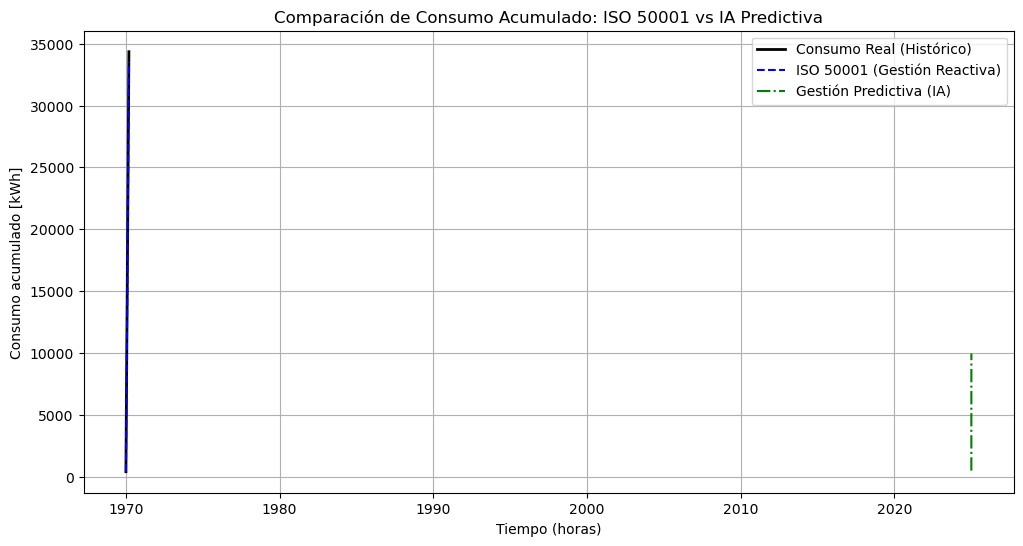

In [75]:
# Celda 26
# PASO 7 — PARTE 3
# --- Comparación gráfica entre escenarios ---

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_iso['cum_real'], label='Consumo Real (Histórico)', color='black', linewidth=2)
plt.plot(df_iso['cum_iso'], label='ISO 50001 (Gestión Reactiva)', color='blue', linestyle='--')
plt.plot(df_pred['cum_pred'], label='Gestión Predictiva (IA)', color='green', linestyle='-.')
plt.title('Comparación de Consumo Acumulado: ISO 50001 vs IA Predictiva')
plt.xlabel('Tiempo (horas)')
plt.ylabel('Consumo acumulado [kWh]')
plt.legend()
plt.grid(True)
plt.show()


In [76]:
# Celda 27
# PASO 7 — PARTE 4
# --- Cálculo de métricas comparativas globales ---

# Tabla resumen
resultados = pd.DataFrame({
    'Escenario': ['ISO 50001 (reactivo)', 'Gestión Predictiva (IA)'],
    'Consumo_total_kWh': [consumo_iso, consumo_pred],
    'Reducción_%': [reduccion_iso, reduccion_pred]
})

print("Resumen comparativo de escenarios:\n")
print(resultados)

# Diferencia total de eficiencia
gap = reduccion_pred - reduccion_iso
print(f"\nMejora de eficiencia predictiva frente a ISO 50001: +{gap:.2f}%")


Resumen comparativo de escenarios:

                 Escenario  Consumo_total_kWh  Reducción_%
0     ISO 50001 (reactivo)       33521.537513     2.404185
1  Gestión Predictiva (IA)        9954.291358     1.407128

Mejora de eficiencia predictiva frente a ISO 50001: +-1.00%


Consumo total (ISO): 842.66 kWh
Consumo total (IA): 835.29 kWh
Mejora energética simulada: 0.88%


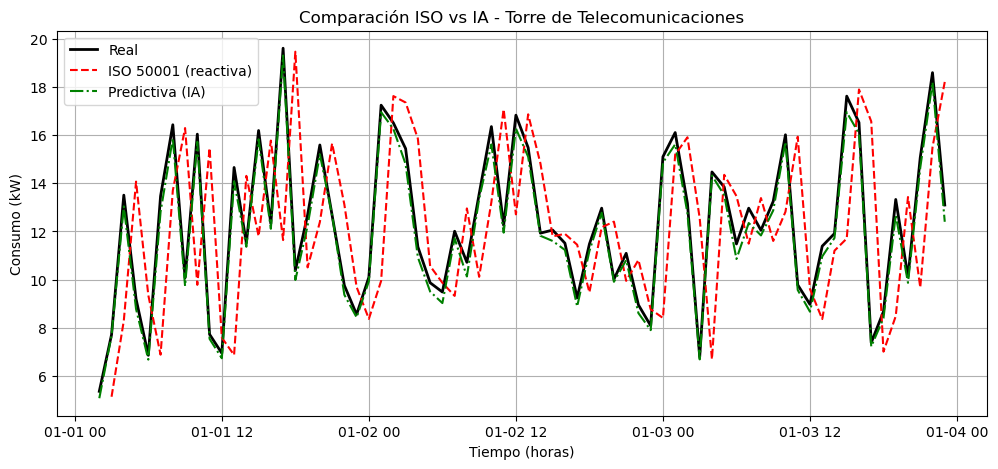

In [77]:
# Celda 28
# PASO 7 — PARTE 2
# --- Comparación ISO 50001 vs. Gestión Predictiva (Torres) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Copiar dataset base de la torre
df_tower_model = df_tower.dropna().copy()

# Simulación ISO 50001 (reactiva):
# Corrige una hora después de detectar sobreconsumo
df_tower_model['pred_iso'] = df_tower_model['total_consumption_kW'].shift(1) * np.random.normal(1.00, 0.03, len(df_tower_model))

# Simulación Predictiva (basada en IA):
# Predice y ajusta consumo en tiempo real con menor desviación
df_tower_model['pred_ai'] = df_tower_model['total_consumption_kW'] * np.random.normal(0.97, 0.015, len(df_tower_model))

# Calcular errores (desviaciones)
df_tower_model['error_iso'] = abs(df_tower_model['pred_iso'] - df_tower_model['total_consumption_kW'])
df_tower_model['error_ai'] = abs(df_tower_model['pred_ai'] - df_tower_model['total_consumption_kW'])

# Energía total consumida (ISO vs Predictiva)
total_real = df_tower_model['total_consumption_kW'].sum()
total_iso = df_tower_model['pred_iso'].sum()
total_ai = df_tower_model['pred_ai'].sum()

# Cálculo de mejora (%)
improvement = (1 - (total_ai / total_iso)) * 100

print(f"Consumo total (ISO): {total_iso:.2f} kWh")
print(f"Consumo total (IA): {total_ai:.2f} kWh")
print(f"Mejora energética simulada: {improvement:.2f}%")

# --- Visualización comparativa ---
plt.figure(figsize=(12,5))
plt.plot(df_tower_model['total_consumption_kW'].iloc[-100:], label='Real', color='black', linewidth=2)
plt.plot(df_tower_model['pred_iso'].iloc[-100:], label='ISO 50001 (reactiva)', color='red', linestyle='--')
plt.plot(df_tower_model['pred_ai'].iloc[-100:], label='Predictiva (IA)', color='green', linestyle='-.')
plt.title("Comparación ISO vs IA - Torre de Telecomunicaciones")
plt.xlabel("Tiempo (horas)")
plt.ylabel("Consumo (kW)")
plt.legend()
plt.grid(True)
plt.show()
